# Data Science with Python Internship – Task 3

## Mini Exploratory Data Analysis (EDA) on Titanic Dataset

### Objective
The objective of this task is to perform Exploratory Data Analysis (EDA)
on the Titanic dataset by cleaning missing data, performing groupby analysis,
and creating meaningful visualizations to understand passenger survival patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [2]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.shape

(891, 15)

In [4]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Fill missing Age with mean.

In [8]:
mean_age = df["age"].mean()

df["age"] = df["age"].fillna(mean_age)

print("Mean Age:", mean_age)

Mean Age: 29.69911764705882


In [9]:
df["age"].isnull().sum()

np.int64(0)

In [10]:
df = df.drop(columns=["deck"])

In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [12]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [13]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [14]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


Survival rate by Family size (SibSp + Parch)

In [15]:
df["family_size"] = df["sibsp"] + df["parch"]

df[["sibsp", "parch", "family_size"]].head()

,sibsp,parch,family_size
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [16]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["age", "age_group"]].head()

,age,age_group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult


Survival rate by Age Group.

In [17]:
age_survival = df.groupby("age_group", observed=True)["survived"].mean()

age_survival

,survived
age_group,
Child,0.579710
Teenager,0.428571
Young Adult,0.353271
Adult,0.400000
Senior,0.227273


In [18]:
age_survival_percentage = age_survival * 100

age_survival_percentage

,survived
age_group,
Child,57.971014
Teenager,42.857143
Young Adult,35.327103
Adult,40.000000
Senior,22.727273


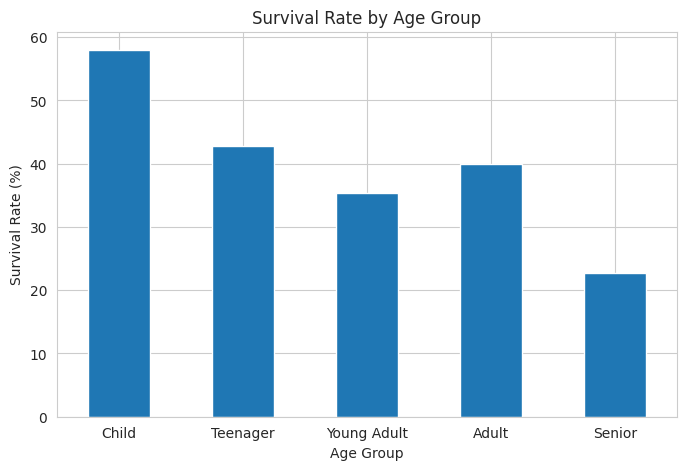

In [19]:
plt.figure(figsize=(8, 5))

age_survival_percentage.plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

Survival rate by Embarkation Port.

In [20]:
port_survival = df.groupby("embarked")["survived"].mean() * 100

port_survival

,survived
embarked,
C,55.357143
Q,38.961039
S,33.900929


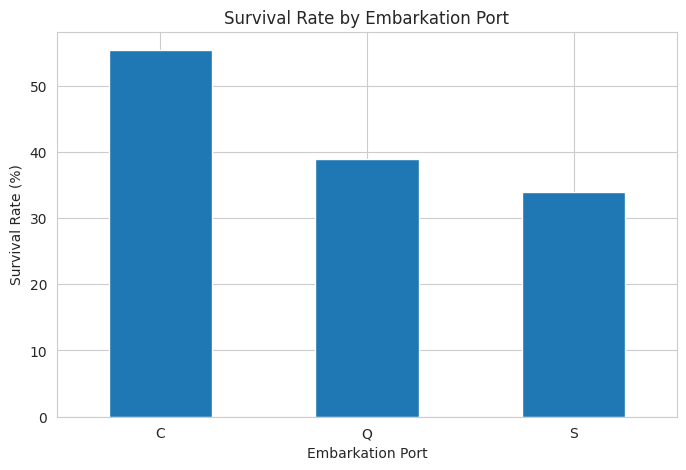

In [21]:
plt.figure(figsize=(8, 5))

port_survival.plot(kind="bar")

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

Family size = SibSp + Parch.

In [22]:
family_survival = df.groupby("family_size")["survived"].mean() * 100

family_survival

,survived
family_size,
0,30.353818
1,55.279503
2,57.843137
3,72.413793
4,20.000000
5,13.636364
6,33.333333
7,0.000000
10,0.000000


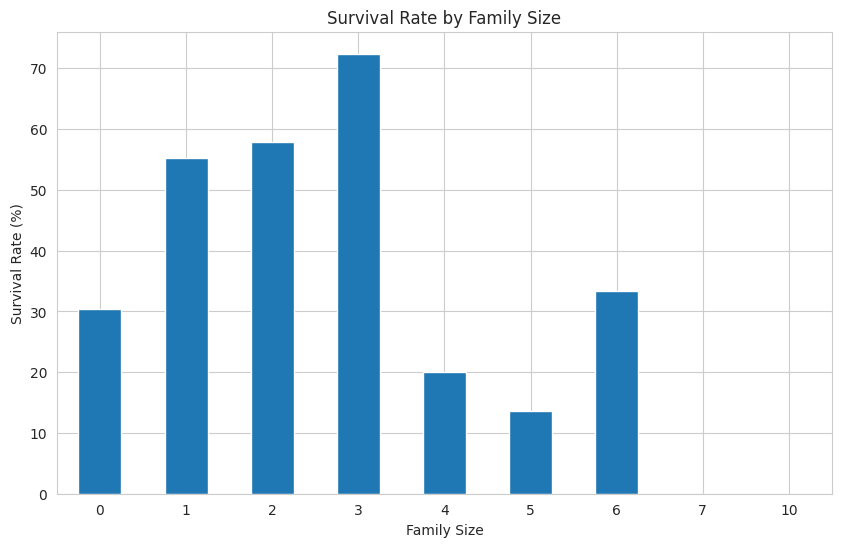

In [23]:
plt.figure(figsize=(10, 6))

family_survival.plot(kind="bar")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

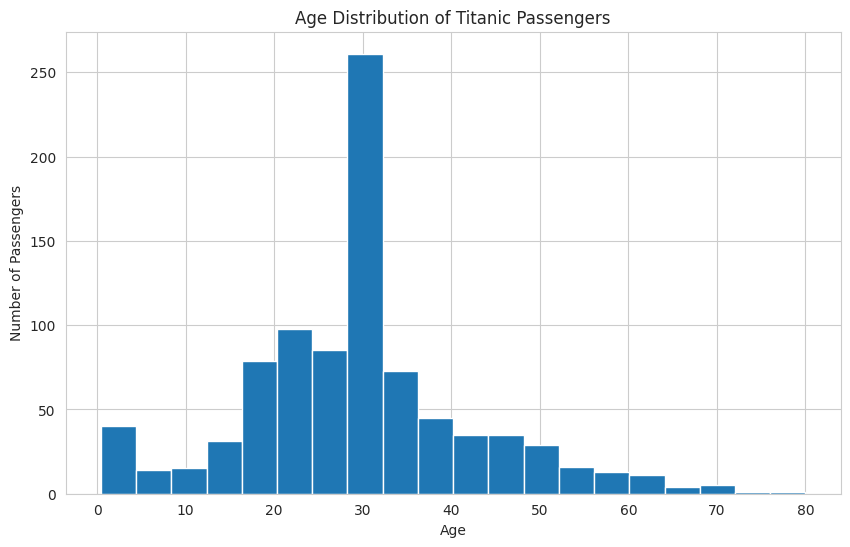

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(df["age"], bins=20)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [25]:
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

correlation

,survived,pclass,age,sibsp,parch,fare,family_size
survived,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,0.016639
pclass,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,0.065997
age,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,-0.248512
sibsp,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,0.890712
parch,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,0.783111
fare,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,0.217138
family_size,0.016639,0.065997,-0.248512,0.890712,0.783111,0.217138,1.000000


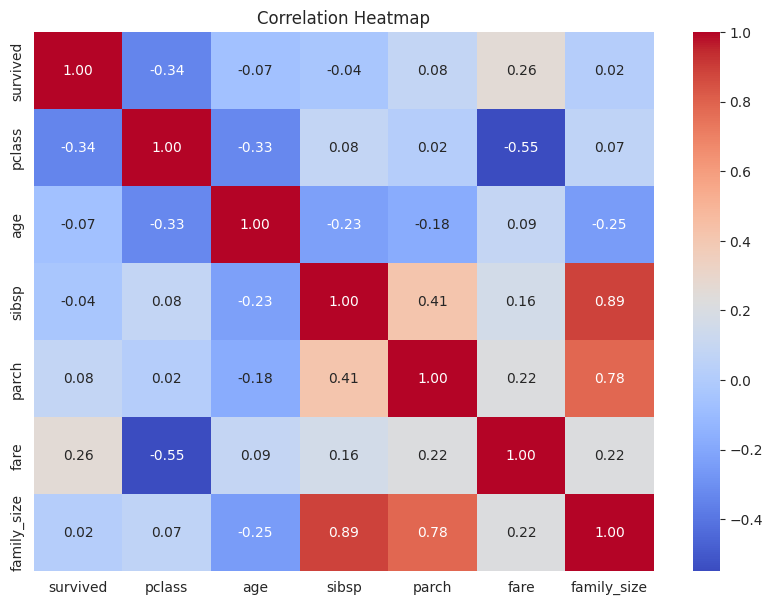

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
gender_survival = df.groupby("sex")["survived"].mean() * 100

gender_survival

,survived
sex,
female,74.203822
male,18.890815


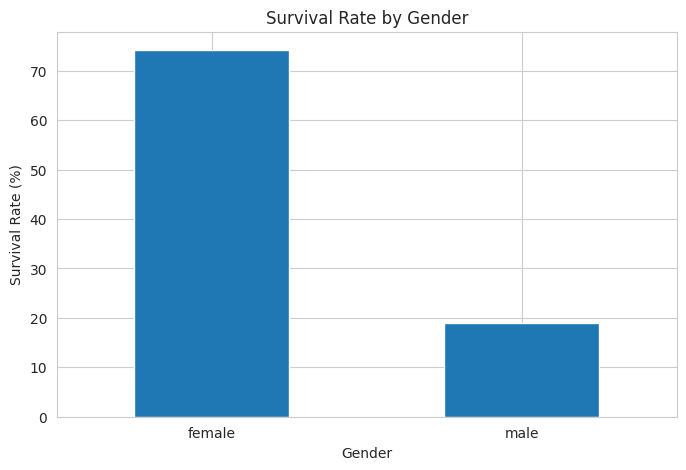

In [28]:
plt.figure(figsize=(8, 5))

gender_survival.plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [29]:
class_survival = df.groupby("pclass")["survived"].mean() * 100

class_survival

,survived
pclass,
1,62.962963
2,47.282609
3,24.236253


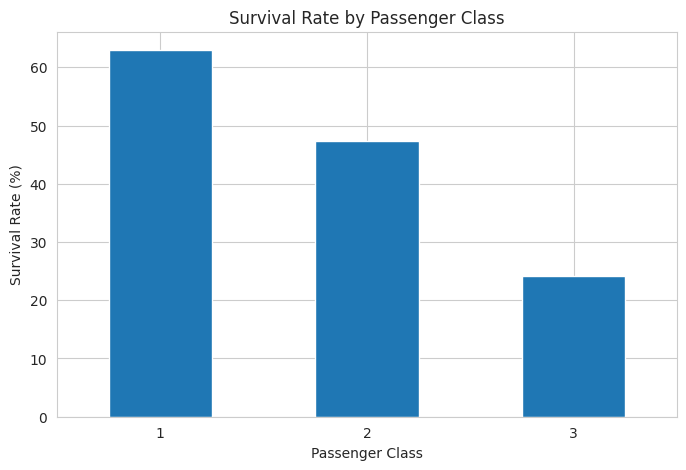

In [30]:
plt.figure(figsize=(8, 5))

class_survival.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

## Key Insights

1. The survival rate varies across different age groups.

2. Passengers from different embarkation ports show different survival rates.

3. Family size has an impact on survival probability. Very small and very
large family groups may show different survival patterns.

4. The age distribution shows that most Titanic passengers were concentrated
within particular age ranges.

5. The correlation heatmap helps identify relationships between numerical
variables such as age, fare, passenger class, family size, and survival.

6. Gender and passenger class also show noticeable differences in survival
rates.

## Conclusion

In this task, Exploratory Data Analysis was performed on the Titanic dataset.
Missing Age values were handled using mean imputation, and irrelevant data
was removed.

Groupby analysis was used to investigate survival rates across age groups,
embarkation ports, and family sizes. Several visualizations including an age
distribution histogram, correlation heatmap, and family-size survival bar
plot were created.

The analysis demonstrates how data cleaning, statistical analysis, and
visualization can be combined to discover meaningful patterns in a dataset.